<a href="https://www.kaggle.com/code/sonawanelalitsunil/imdb-top-5000-movies-ml?scriptVersionId=232876310" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/imdb-top-5000-movies/results_with_crew.csv


## Title: IMDb Top 5000 Movies

#### Description: A curated list of the top 5000 movies from IMDb, featuring the most popular, critically acclaimed, and highest-rated films across various genres and time periods. Perfect for movie enthusiasts looking for a comprehensive collection of the best cinematic experiences.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/imdb-top-5000-movies/results_with_crew.csv')

In [3]:
df.head()

,tconst,primaryTitle,startYear,rank,averageRating,numVotes,runtimeMinutes,directors,writers,genres,IMDbLink,Title_IMDb_Link
0,tt0111161,The Shawshank Redemption,1994,1,9.3,3029407,142,Frank Darabont,"Stephen King, Frank Darabont",Drama,"<a href=""https://www.imdb.com/title/tt0111161""...","<a href=""https://www.imdb.com/title/tt0111161""..."
1,tt0068646,The Godfather,1972,2,9.2,2114342,175,Francis Ford Coppola,"Mario Puzo, Francis Ford Coppola","Crime, Drama","<a href=""https://www.imdb.com/title/tt0068646""...","<a href=""https://www.imdb.com/title/tt0068646""..."
2,tt0468569,The Dark Knight,2008,3,9.0,3005759,152,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...","Action, Crime, Drama","<a href=""https://www.imdb.com/title/tt0468569""...","<a href=""https://www.imdb.com/title/tt0468569""..."
3,tt0167260,The Lord of the Rings: The Return of the King,2003,4,9.0,2068876,201,Peter Jackson,"J.R.R. Tolkien, Fran Walsh, Philippa Boyens, P...","Adventure, Drama, Fantasy","<a href=""https://www.imdb.com/title/tt0167260""...","<a href=""https://www.imdb.com/title/tt0167260""..."
4,tt0108052,Schindler's List,1993,5,9.0,1515877,195,Steven Spielberg,"Thomas Keneally, Steven Zaillian","Biography, Drama, History","<a href=""https://www.imdb.com/title/tt0108052""...","<a href=""https://www.imdb.com/title/tt0108052""..."


In [4]:
df.tail()

,tconst,primaryTitle,startYear,rank,averageRating,numVotes,runtimeMinutes,directors,writers,genres,IMDbLink,Title_IMDb_Link
4995,tt0880578,Untraceable,2008,4996,6.2,54012,101,Gregory Hoblit,"Robert Fyvolent, Mark Brinker, Allison Burnett","Crime, Mystery, Thriller","<a href=""https://www.imdb.com/title/tt0880578""...","<a href=""https://www.imdb.com/title/tt0880578""..."
4996,tt27459160,Teri Baaton Mein Aisa Uljha Jiya,2024,4997,6.2,53979,141,"Amit Joshi, Aradhana Sah","Amit Joshi, Aradhana Sah","Comedy, Drama, Romance","<a href=""https://www.imdb.com/title/tt27459160...","<a href=""https://www.imdb.com/title/tt27459160..."
4997,tt3174376,Before I Wake,2016,4998,6.2,53934,97,Mike Flanagan,"Mike Flanagan, Jeff Howard","Drama, Fantasy, Horror","<a href=""https://www.imdb.com/title/tt3174376""...","<a href=""https://www.imdb.com/title/tt3174376""..."
4998,tt5177088,The Girl in the Spider's Web,2018,4999,6.1,53870,115,Fede Alvarez,"Jay Basu, Fede Alvarez, Steven Knight, Stieg L...","Action, Adventure, Crime","<a href=""https://www.imdb.com/title/tt5177088""...","<a href=""https://www.imdb.com/title/tt5177088""..."
4999,tt8368408,Gunpowder Milkshake,2021,5000,6.1,53710,114,Navot Papushado,"Navot Papushado, Ehud Lavski","Action, Crime, Thriller","<a href=""https://www.imdb.com/title/tt8368408""...","<a href=""https://www.imdb.com/title/tt8368408""..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           5000 non-null   object 
 1   primaryTitle     5000 non-null   object 
 2   startYear        5000 non-null   int64  
 3   rank             5000 non-null   int64  
 4   averageRating    5000 non-null   float64
 5   numVotes         5000 non-null   int64  
 6   runtimeMinutes   5000 non-null   int64  
 7   directors        5000 non-null   object 
 8   writers          4974 non-null   object 
 9   genres           5000 non-null   object 
 10  IMDbLink         5000 non-null   object 
 11  Title_IMDb_Link  5000 non-null   object 
dtypes: float64(1), int64(4), object(7)
memory usage: 468.9+ KB


In [6]:
df.isnull().sum()

tconst              0
primaryTitle        0
startYear           0
rank                0
averageRating       0
numVotes            0
runtimeMinutes      0
directors           0
writers            26
genres              0
IMDbLink            0
Title_IMDb_Link     0
dtype: int64

In [7]:
df.isnull().sum().sum()

26

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(5000, 12)

In [10]:
df.dtypes

tconst              object
primaryTitle        object
startYear            int64
rank                 int64
averageRating      float64
numVotes             int64
runtimeMinutes       int64
directors           object
writers             object
genres              object
IMDbLink            object
Title_IMDb_Link     object
dtype: object

In [11]:
df.columns

Index(['tconst', 'primaryTitle', 'startYear', 'rank', 'averageRating',
       'numVotes', 'runtimeMinutes', 'directors', 'writers', 'genres',
       'IMDbLink', 'Title_IMDb_Link'],
      dtype='object')

## Data visualizations

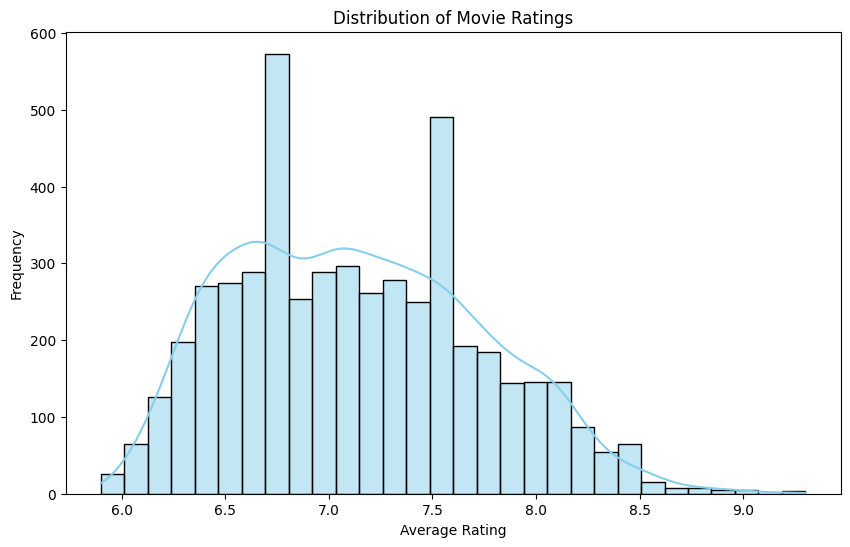

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df['averageRating'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Frequency')
plt.show()

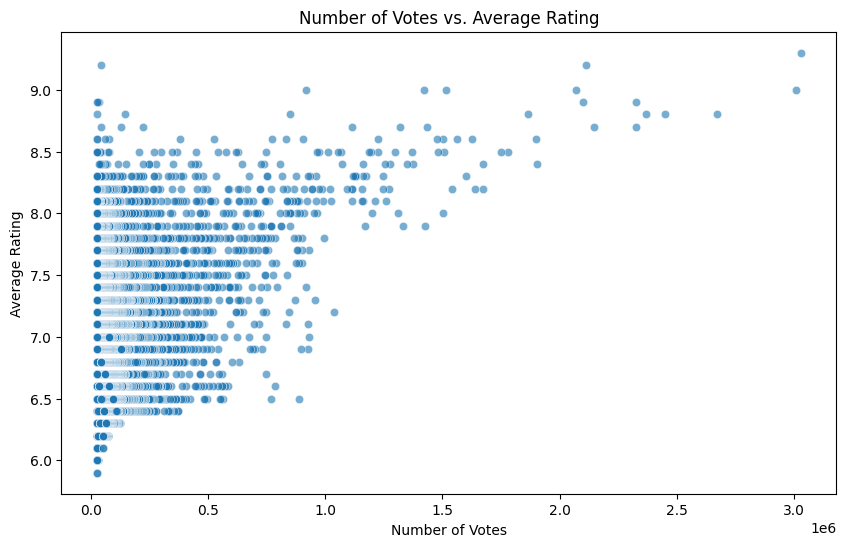

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='numVotes', y='averageRating', data=df, alpha=0.6)
plt.title('Number of Votes vs. Average Rating')
plt.xlabel('Number of Votes')
plt.ylabel('Average Rating')
plt.show()

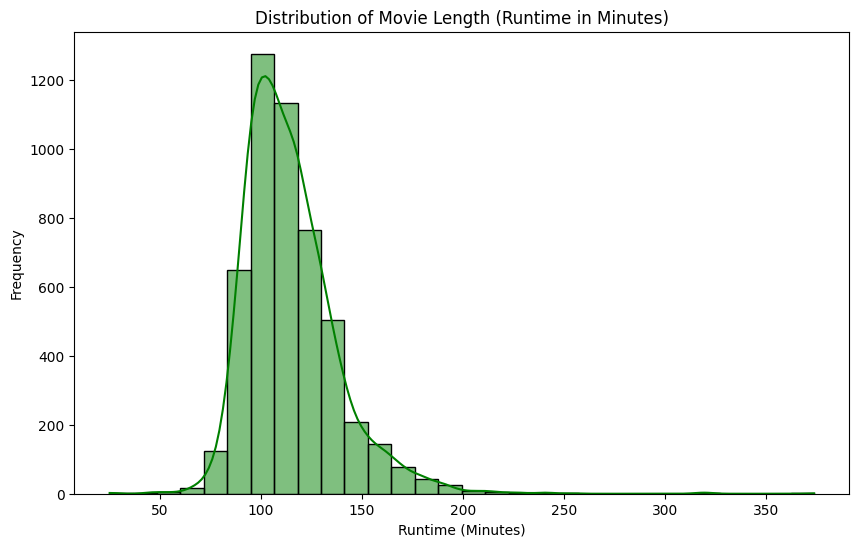

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df['runtimeMinutes'], bins=30, kde=True, color='green')
plt.title('Distribution of Movie Length (Runtime in Minutes)')
plt.xlabel('Runtime (Minutes)')
plt.ylabel('Frequency')
plt.show()

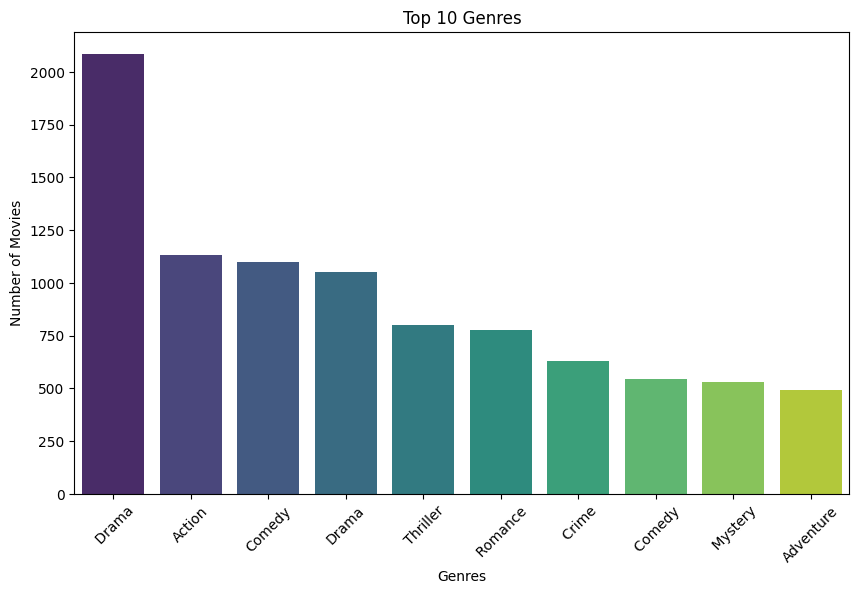

In [15]:
genre_counts = df['genres'].str.split(',').explode().value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')
plt.title('Top 10 Genres')
plt.xlabel('Genres')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

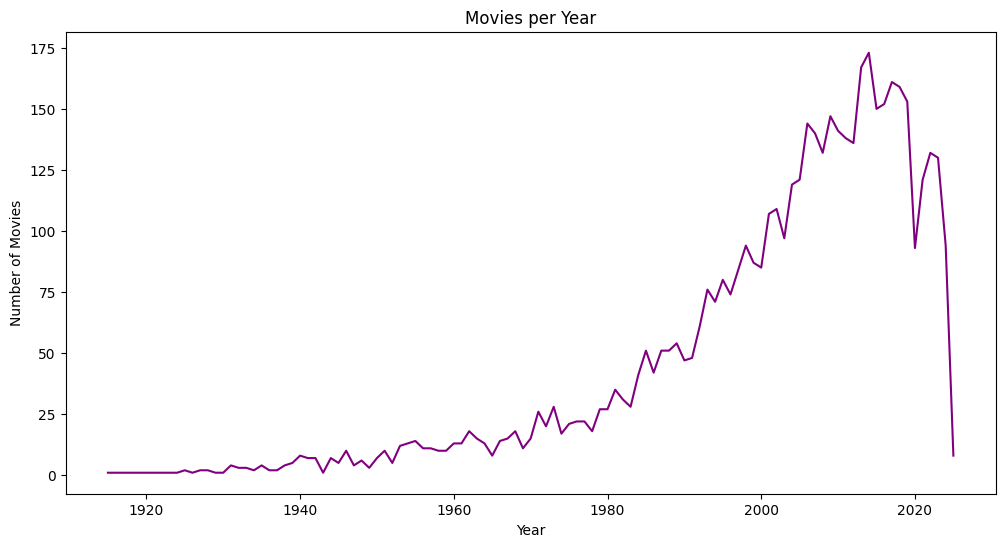

In [16]:
movies_per_year = df['startYear'].value_counts().sort_index()
plt.figure(figsize=(12,6))
movies_per_year.plot(kind='line', color='purple')
plt.title('Movies per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

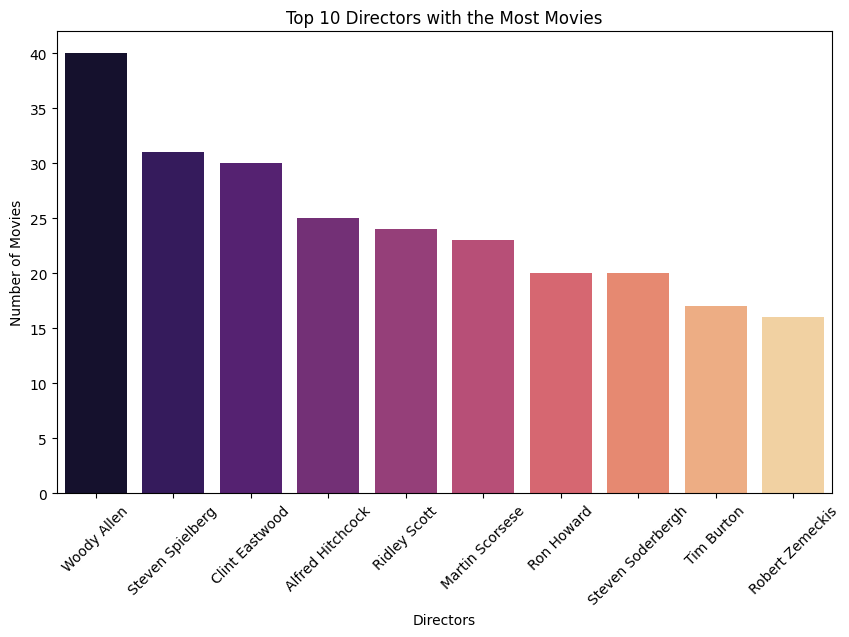

In [17]:
# Top directors by number of movies
director_counts = df['directors'].str.split(',').explode().value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=director_counts.index, y=director_counts.values, palette='magma')
plt.title('Top 10 Directors with the Most Movies')
plt.xlabel('Directors')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()


## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [19]:
df = df.dropna()

In [20]:
le = LabelEncoder()

# Encoding 'genres' and 'directors' (you might need to preprocess these columns further)
df['genres'] = df['genres'].fillna('Unknown')
df['directors'] = df['directors'].fillna('Unknown')
df['genres_encoded'] = le.fit_transform(df['genres'])
df['directors_encoded'] = le.fit_transform(df['directors'])

In [21]:
# Select features and target column
X = df[['averageRating', 'numVotes', 'runtimeMinutes', 'genres_encoded', 'directors_encoded']]
y = df['rank'] 

In [22]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
# List of classifiers to evaluate
classifiers = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

In [24]:
# Train and evaluate each classifier
for clf_name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Accuracy
    accuracy = accuracy_score(y_test, y_pred) * 100
    print(f'{clf_name} Accuracy: {accuracy:.2f}%')
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

Logistic Regression Accuracy: 0.00%
Decision Tree Accuracy: 0.00%
Random Forest Accuracy: 0.00%
SVM Accuracy: 0.00%
KNN Accuracy: 0.00%
Naive Bayes Accuracy: 0.00%


## Thank you...pls upvote!!!!